In this post we'll look at jump processes.
A jump process is what it sounds like.
I'm interested in them because they seem like a natural model for iceberg calving.
They've also been used as models for rainfall, earthquakes, landslides, [droughts](https://doi.org/10.1007/BF01581675), and other processes in the earth sciences.
In finance, jump processes are used to model the effects of sudden economic downturns or shocks.
For example a company's stock price might experience a shock when it becomes public knowledge that the CEO was doing business with Jeffrey Epstein.

Anyway it takes two pieces of information to characterize a jump process.
First is how frequently events occur, and second is the distribution of jump sizes.

The most common starting point is to assume that the time between events follows an exponential distribution.
A continuous-time jump process is a Markov process if and only if the waiting time is exponential.
This is a strong assumption.
The exponential distribution is memoryless and it's kind of hard to find real processes that we think should have no memory.
I'll discuss alternatives at the end.

Here I'll assume that the jumps also have an exponential distribution.
That assumption makes the math work out nice.
They could also be normal or whatever you like, but in any case it's convenient if they're [infinitely divisible](https://en.wikipedia.org/wiki/Infinite_divisibility_(probability)).
The jump process that we'll describe is a particular example of a [renewal-reward process](https://en.wikipedia.org/wiki/Renewal_theory).

First I'll show some sample paths of jump processes so you can see what they look like.
Then we'll do a mess of math in order to look at the probability density of the process at some finite time $t$.
We'll need to have a closed-form expression for this probability density if we want to be able to infer the parameters of the process.
I'll get to inference in a later post.

### Simulation

In [1]:
from dataclasses import dataclass
import numpy as np
from numpy import sqrt, exp
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import scipy.special
import sympy
from tqdm.notebook import trange, tqdm

I'm going to make a class to represent a jump process because it'll be handy in a moment.
An object representing a jump process needs to keep track of all the times where jumps occur and the values.
We'll want a method to evaluate a path a particular time so that we can explore what happens when we sample it at discrete intervals, and we'll want a method to plot a path.
Probably the hardest thing about studying jump processes is plotting them.

In [2]:
@dataclass
class JumpProcessPath:
    times: np.ndarray
    values: np.ndarray

    def __call__(self, time: float) -> float:
        index = np.searchsorted(self.times, time, side="right")
        return self.values[index]

    def to_line_collection(self, *args, **kwargs) -> LineCollection:
        segment = [(self.times[0], self.values[0])]
        for k in range(len(self.times) - 1):
            t1, t2 = self.times[k:k + 2]
            x1, x2 = self.values[k: k + 2]
    
            segment.append((t2, x1))
            segment.append((t2, x2))
    
        return LineCollection([segment], *args, **kwargs)

We can express a compound Poisson process as a sum of all the random jumps, but where the final index of the sum is a random variable:
$$X(t) = \sum_{n = 1}^{N(t)}J_n$$
The code below simulates a compound Poisson process.
I'd argue that the code is easier to understand than the math.

In [3]:
def simulate(T: float, λ: float, τ: float, rng) -> JumpProcessPath:
    ts, xs = [0.0], [0.0]
    while ts[-1] < T:
        δt = rng.exponential(scale=τ)
        δx = rng.exponential(scale=λ)
        ts.append(ts[-1] + δt)
        xs.append(xs[-1] + δx)

    return JumpProcessPath(times=np.array(ts), values=np.array(xs))

We'll plot a few sample paths below.
The black line shows the mean displacement.

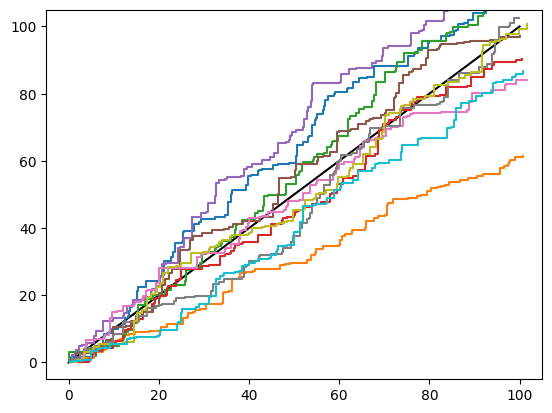

In [4]:
rng = np.random.default_rng(seed=1729)
λ = 1
τ = 1
f = 100

fig, ax = plt.subplots()
ax.plot(ts := np.linspace(0.0, f * τ, 2), λ / τ * ts, color="black")
for color in matplotlib.colors.TABLEAU_COLORS:
    path = simulate(f * τ, λ, τ, rng)
    collection = path.to_line_collection(color=color)
    ax.add_collection(collection)

It's also common to study the *compensated* process $X(t) - \lambda\cdot t/\tau$, which has mean 0.

### Likelihood function

Now let's suppose instead that we know a process is compound Poisson, but we don't know what the parameters are.
We'll write these observations as $\{t_k\}$, $\{x_k\}$.
The classic way to estimate these parameters from measurements is maximum likelihood estimation.
In order to do maximum likelihood estimation, we need an analytical expression for the probability of obtaining the measurements we got.
Here I'd like to derive a closed form of this likelihood function.

The increments of a compound Poisson process are homogeneous.
So we can write the likelihood as a product of independent events:
$$L(\{x_k\}, \{t_k\}; \lambda, \tau) = \prod_k\ell(x_{k + 1} - x_k, t_{k + 1} - t_k; \lambda, \tau).$$
Our hard problem now boils down to computing the probability that, starting at $X(s)$, the process jumps by a distance $x$ by time $s + t$.
The final step is a little technical but at the end we get a closed form.

#### Conditioning on number of jumps

We can start by breaking up the likelihood using conditional probability.
The likelihood of a total change of size $x$ can be broken up using conditional probability.
First, we condition on the event that there are $n$ jumps in the interval $[s, s + t]$, and then on the event that the sum of the jump sizes is equal to $x$:
$$\begin{align}
& \ell(x, t; \lambda, \tau) \equiv P[X(s + t) - X(s) = x] = P\left[\sum_{k = N(s)}^{N(s + t)}J_k = x\right] \\
& \quad = \sum_{n = 0}^\infty P\left[\sum_{k = N(s)}^{N(s + t)}J_k = x \,|\, N(s + t) - N(s) = n\right]\cdot P[N(s + t) - N(s) = n] \ldots
\end{align}$$
Now we use the assumptions that we made about the distributions of the inter-arrival times and the jump sizes.
The inter-arrival times are a Poisson process, so
$$P[N(s + t) - N(s) = n] = \text{Poisson}(t/\tau; n).$$
The jumps are i.i.d. exponential random variables.
The sum of $n$ exponential random variables has a Gamma distribution:
$$P\left[\sum_{k = N(s)}^{N(s + t)}J_k = x \,|\, N(s + t) - N(s) = n\right] = \text{Gamma}(x; n, \lambda).$$

There's a curveball here.
What if there are no jumps at all in the interval $[s, s + t]$?
This is always possible.
If $t$ is close to or less than the average inter-arrival time $\delta t$, it's not just possible but likely.
So we have to separate out the likelihood into two terms: one for the probability that there are no jumps at all, and another for when there are jumps:
$$\ldots = \sum_{n = 1}^\infty\underbrace{\text{Gamma}(x; n, \lambda)\cdot\text{Poisson}(t/\tau; n)}_{\text{jumps}} \quad + \quad \underbrace{\delta(x)\cdot\text{Poisson}(t/\tau; 0)}_{\text{no jumps}}\ldots$$
where $\delta(x)$ is the point mass at 0.

#### Special function magic

We can complete the derivation by substituting in expressions for the Poisson and Gamma distributions:
$$\begin{align}
\ell(x, t; \lambda, \tau) & = \sum_{n = 1}^\infty\underbrace{\text{Gamma}(x; n, \lambda)\cdot\text{Poisson}(t/\tau; n)}_{\text{jumps}} + \underbrace{\delta(x)\cdot\text{Poisson}(t/\tau; 0)}_{\text{no jumps}} \\
& = \sum_{n = 1} \left\{\frac{e^{-x/\lambda}\left(\frac{x}{\lambda}\right)^n}{x\,\Gamma(n)}\right\}\left\{\frac{e^{-t/\tau}\left(\frac{t}{\tau}\right)^n}{n!}\right\} + \delta(x)\cdot e^{-t/\tau}\\
& = x^{-1}e^{-x/\lambda}e^{-t/\tau}\sum_{n = 1}\frac{\left(\frac{x}{\lambda}\right)^n\left(\frac{t}{\tau}\right)^n}{n!(n - 1)!} + \delta(x)\cdot e^{-t/\tau} \ldots
\end{align}$$
where in the second line I've rearranged some terms and used the fact that $\Gamma(n) = (n - 1)!$ for natural numbers $n$.
To progress, we need to know a closed form expression for $\sum_n \frac{z^n}{n!(n - 1)!}$.
It's probably some kind of hypergeometric function (aren't they all).
I consulted the [engineer's best friend](https://www.wolframalpha.com/input?i=sum+from+n+%3D+1+to+infinity+of+z%5En+%2F+%28n%21+*+%28n+-+1%29%21%29) and found that we can write it in terms of the [modified Bessel function of the first kind](en.wikipedia.org/wiki/Bessel_function#Modified_Bessel_functions):
$$\sum_{n = 1}\frac{z^n}{n!(n - 1)!} = \sqrt z \;I_1(2\sqrt z).$$
So our final answer is
$$\ldots = \lambda^{-1}\sqrt{\frac{t/\tau}{x/\lambda}}e^{-x/\lambda}e^{-t/\tau} I_1\left(2\sqrt{\frac{x}{\lambda}}\sqrt{\frac{t}{\tau}}\right) + \delta(x)\cdot e^{-t/\tau}.$$
I've grouped the terms in order to be able to express the likelihood as a function of the ratios $t/\tau$, $x/\lambda$.

#### Sanity checking asymptotic behavior

We should look at how $I_1$ behaves around 0 and infinity in order to make sure this expression doesn't do anything goofy.
The thing we're looking at is a probability density; it needs to be positive and integrate to 1.
If anything about what we wrote down contradicts that, then we know there's a mistake.

First, the modified Bessel function grows at infinity.
Suppose that it grows faster than the factors of $e^{-x / \lambda}e^{-t/\tau}$ are decreasing.
Our candidate expression for a probability density won't decay to 0, so it can't have a finite integral.
Now the real asymptotic behavior is
$$I_\alpha(z) \sim \frac{e^z}{\sqrt{2\pi z}}$$
as $z \to \infty$.
The square roots in the argument mean that the first term goes like $e^{-x/\lambda + \sqrt{x/\lambda}}$ as $x \to \infty$ and likewise for $t$.
Eventually the $-x/\lambda$ term in the exponential will dominate the $+\sqrt{x/\lambda}$ term, so the whole expression will go to zero as we had hoped.

There's also a factor of $\sqrt{x/\lambda}$ in the denominator.
Unless the Bessel function term is going to compensate, that expression could go to infinity as $x \to 0$.
A function with an inverse square root singularity at a point can still have a finite integral.
A potential singularity is still worth investigating.
Around 0,
$$I_\alpha(z) \sim \frac{1}{\Gamma(\alpha + 1)}\left(\frac{z}{2}\right)^\alpha.$$
So for small values of $\lambda$, $t$,
$$P[X(s + t) - X(s) = x] \sim t/\tau \times \text{const} + \delta(x).$$
There's no singularity at all in the first term.
As we expect, the likelihood of a finite jump size goes to zero as $t \to 0$.

From a math perspective, it's nice that the singularity at 0 is removable.
We might run into numerical difficulties when we go to write code.
Removable singularities are exactly what floating-point arithmetic is bad at.

#### Visualization

The character of the log-likelihood function is going to be important for us when we go to do inference.
The nicest outcome possible is that the log-likelihood function is concave.
Concavity guarantees that the log-likelihood has a unique maximizer and that Newton-type methods can locate this maximizer.

The easiest way to get a feel for the character of the log-likelihood is to make a contour plot of its continuous part for a single observation as a function of $x/\lambda$ and $t/\tau$.
We can then imagine that the full log-likelihood as a sum of many single-observations, but with the $x$- and $t$-axes scaled differently for each summand.
Here I'm making a symbolic representation of the likelihood using sympy.
We can then use the `lambdify` function to turn this into something we can call on numpy arrays.

In [5]:
from sympy import besseli, sqrt, exp

def likelihood_0(x, t, λ, τ):
    r_t = t / τ
    return exp(-r_t)


def likelihood_positive(x, t, λ, τ):
    r_t = t / τ
    r_x = x / λ

    return sqrt(r_t / r_x) * exp(-r_x - r_t) * besseli(1, 2 * sqrt(r_t * r_x)) / λ


def likelihood(x, t, λ, τ):
    return sympy.Piecewise(
        (likelihood_0(x, t, λ, τ), x <= 0),
        (likelihood_positive(x, t, λ, τ), x > 0),
    )

In [6]:
x_, t_, λ_, τ_ = sympy.symbols("x t λ τ", real=True, nonnegative=True)
ℓ = likelihood(x_, t_, λ_, τ_)
args = ((x_, t_), λ_, τ_)
L = sympy.lambdify(args, ℓ, "scipy")

The contour plot below shows the log-likelihood for a single observation.

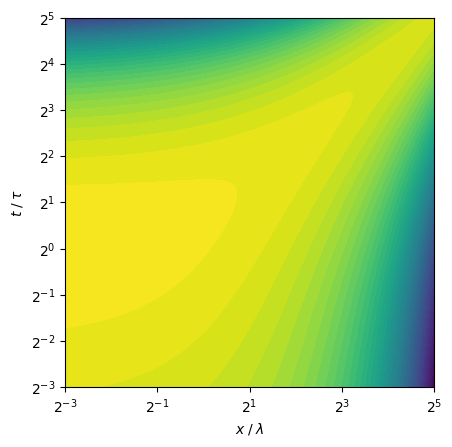

In [7]:
xs = np.logspace(-3, +5, 101, base=2)
ts = np.logspace(-3, +5, 101, base=2)
Xs, Ts = np.meshgrid(xs, ts)
Ls = L((Xs, Ts), 1, 1)

fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.set_xscale("log", base=2)
ax.set_yscale("log", base=2)
ax.set_xlabel("$x\\;/\\; \\lambda$")
ax.set_ylabel("$t\\;/\\; \\tau$")
ax.contourf(Xs, Ts, np.log(Ls), 50);

**This plot is bad news.**
The log-likelihood is not concave.
It doesn't even have concave super-level sets.
That means that there is no hope of transforming it into something that is concave by composing with some monotonic function.
We can't rule out the chance that the full log-likelihood is going to have multiple local extrema.

That's going to have important implications for what kind of optimization algorithms we should use.
For a concave function, we could evaluate whether a candidate solution is close enough by examining the magnitude of the gradient and the eigenvalues of the curvature operator.
That same analysis on an objective that isn't convex or concave only tells us how close we are to the nearest local extremum.
A global method that explores the entire search space can give better assurances.
There are only two parameters to infer, so the cost isn't too extreme.

The character of the likelihood function should make us wonder if there are scenarios where the jump time and size aren't identifiable.
For example, suppose the inter-arrival time is much smaller than our sampling interval.
We might have no sampling intervals where there were no events.
We can't meaningfully distinguish between an event timing and size of $\tau$, $\lambda$ and $\tau/2$, $\lambda/2$.
The only quantity we can infer is the flux $\lambda/\tau$.

#### Sanity checking through visualization

Finally, we can generate a giant mess of sample paths and see how well our theoretical likelihood function matches the empirical one.

In [8]:
num_trials = 10000

T = f * τ
sample_times = np.arange(0, T, τ / 4)
num_samples = len(sample_times)
sample_values = np.zeros((num_trials, num_samples))
for trial in trange(num_trials):
    path = simulate(T, λ, τ, rng)
    sample_values[trial] = path(sample_times)

  0%|          | 0/10000 [00:00<?, ?it/s]

The movie below shows a histogram of the displacements at each time and the theoretical likelihood function.

In [9]:
%%capture

fig, ax = plt.subplots()
ax.set_xlabel("distance")
ax.set_ylabel("density")

num_bins = 100
ax.hist(sample_values[:, 0], num_bins)
xs = np.linspace(1e-4, λ * T / τ, 101)

def animate(time_index):
    ax.clear()
    ax.set_xlim((-λ / τ, λ * (T + 1) / τ))
    ax.set_ylim((0, 0.1))
    ax.hist(sample_values[:, time_index], num_bins, density=True)

    Ls = L((xs, sample_times[time_index] * np.ones_like(xs)), λ, τ)
    ax.plot(xs, Ls, color="black")

In [10]:
indices = trange(len(sample_times))
animation = FuncAnimation(fig, animate, indices, interval=1e3/30)

  0%|          | 0/400 [00:00<?, ?it/s]

In [11]:
HTML(animation.to_html5_video())

The histogram looks a bit biased but good enough in the eyeball norm.

One final thing we'll want to investigate is how the histograms look in the neighborhood of zero for the first sampling times.
We've sampled the time series at an interval of $\tau / 4$.
At least up until about $3\cdot\tau$, we should be able to see a few sample paths where no jump occurred at all.
The probability of no jump decreases exponentially in time.

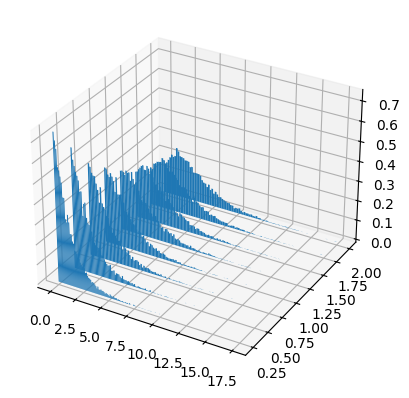

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

for index in range(1, 9):
    hist, bins = np.histogram(sample_values[:, index], bins=num_bins, density=True)
    xs = (bins[:-1] + bins[1:]) / 2
    width = bins[1:] - bins[:-1]
    kw = {"width": width, "zdir": "y", "color": "tab:blue"}
    ax.bar(xs, hist, zs=sample_times[index], **kw);

After less than $10\cdot\tau$, we find that no paths out of all 10,000 trials had no displacement.

In [13]:
δxs = (sample_values[:, 1:].T - sample_values[:, 0].T).T
p = np.sum(δxs == 0, axis=0) / num_trials
last_no_jump_time = sample_times[np.flatnonzero(p != 0).max()]
r = last_no_jump_time / τ
print(f"Last time where any sample path has no displacement: {r:0.02f} * τ")

Last time where any sample path has no displacement: 9.00 * τ


### Conclusion

Here I've shown a bit about a particular kind of renewal-reward process.
These jump processes are a reasonble "null hypothesis" model for a host of jump processes in the earth sciences, in the same way that red noise is a good null hypothesis for continuous processes in climate.
An interesting alternative hypothesis might be that the inter-arrival times are not exponentially distributed.
In that case, the process is no longer Markovian.
That's an upsetting outcome because we like Markov processes.
It's also plausible that the event size and waiting time are no longer independent of each other but are instead correlated.
For the simple kind of process we studied here, we were able to compute its probability density function analytically.
We can't expect an analytical solution under either of these alternative hypotheses.

In the next notebook, I'll look at how we can infer the waiting time and jump size from observational data.